In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

# 1) Load the given dataset

In [2]:
cd C:\Users\rjban\Desktop\ml\ML Projects

C:\Users\rjban\Desktop\ml\ML Projects


In [3]:
df = pd.read_csv("ML Project - Logistic Regression Titanic Survival U16955478860.txt")

In [4]:
df.shape

(891, 12)

In [5]:
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 2) Print all the column names

In [6]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

# 3) Describe the data

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# 4) Check the null values

In [8]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# 5) Handle Null values

In [9]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [10]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [11]:
df.drop("Cabin", axis=1, inplace=True)

In [12]:
le = LabelEncoder()

In [13]:
df["Sex"] = le.fit_transform(df["Sex"])

In [14]:
df["Embarked"] = le.fit_transform(df["Embarked"])

In [15]:
df.drop(columns=["PassengerId", "Name", "Ticket"], inplace=True)

In [16]:
df.head(2)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0


In [17]:
df.shape

(891, 8)

# Part-2: Working with Models
# 1) Create target data (y) and feature data (X)

In [18]:
x = df.drop("Survived", axis=1)
y = df["Survived"]

# 2) Split the data into Training and testing Set (80/20 split)

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3) Create a Logistic regression model

In [20]:
log_reg = LogisticRegression(max_iter=1000)

In [22]:
log_reg.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
yp = log_reg.predict(x_test)

In [24]:
yp1 = log_reg.predict_proba(x_test)[:, 1]

# 4) Display the Confusion Matrix

In [25]:
confusion_matrix(y_test,yp)

array([[90, 15],
       [19, 55]])

# 5) Find the Accuracy Score

In [26]:
accuracy_score(y_test,yp)

0.8100558659217877

# 6) Find the Precision Score

In [28]:
precision_score(y_test,yp)

0.7857142857142857

# 7) Find the Recall Score

In [29]:
recall_score(y_test,yp)

0.7432432432432432

# 8) Find the F1 Score

In [30]:
f1_score(y_test,yp)

0.7638888888888888

# 9) Find the probability of testing data (first 5 samples)

In [31]:
yp1

array([0.11388474, 0.22164525, 0.13487275, 0.88563266, 0.74518654,
       0.93066484, 0.67113408, 0.0911982 , 0.74621312, 0.92078515,
       0.33314981, 0.0698742 , 0.38837938, 0.15095946, 0.19750931,
       0.93640145, 0.29995294, 0.67117837, 0.24452367, 0.33022084,
       0.12128138, 0.40707981, 0.61651877, 0.13525761, 0.11052912,
       0.06856061, 0.47050235, 0.22274016, 0.08118053, 0.59952977,
       0.13845454, 0.66310015, 0.56331061, 0.62105644, 0.14217251,
       0.1288257 , 0.45741074, 0.67113408, 0.94221524, 0.10889444,
       0.20102008, 0.08101937, 0.10893236, 0.13196719, 0.57929285,
       0.09118568, 0.13853391, 0.12493005, 0.12105314, 0.33786635,
       0.72343394, 0.80799809, 0.04078119, 0.51077892, 0.04698949,
       0.93205776, 0.21643946, 0.93211856, 0.77656625, 0.72860262,
       0.13131767, 0.85810552, 0.76450955, 0.45139507, 0.13196719,
       0.63404956, 0.31171373, 0.10597128, 0.14966751, 0.87521271,
       0.75520703, 0.94938364, 0.57779105, 0.9041345 , 0.12455

In [32]:
yp1[:5]

array([0.11388474, 0.22164525, 0.13487275, 0.88563266, 0.74518654])

# 10) Display ROC Curve and find the AUC score

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, yp1)

In [34]:
roc_auc = auc(fpr, tpr)

In [35]:
roc_auc

np.float64(0.8823680823680824)

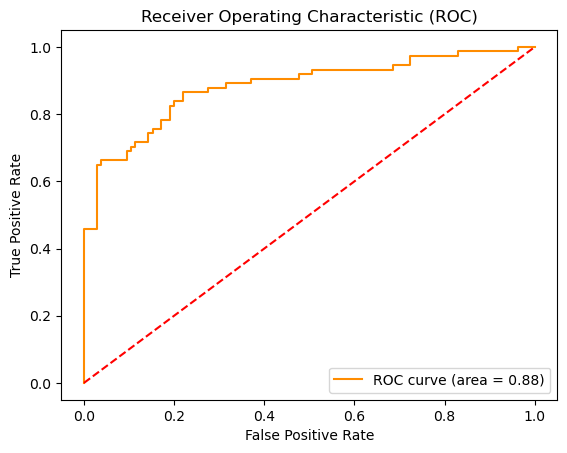

In [37]:
plt.plot(fpr, tpr, color="darkorange", label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.savefig("roc_curve.png")